In [1]:
from fastai.vision.all import *

In [2]:
from make import load_secondary_data
from pathlib import Path
import os

spec, labels = load_secondary_data()


Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [4]:
from validation_util import split

valid_spec, valid_labels = split(spec, labels, 60)

In [5]:
print(f'Initial shape of a spectrogram: ', spec[0].shape)

ch, freq_bins = spec[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (129, 35)
Final shape: (129, 9)


In [6]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [7]:
def get_x(i):
    arr = spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
            arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)

In [10]:
block = DataBlock(
    blocks=(TransformBlock(), TransformBlock()),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_x,
)

In [11]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=8)

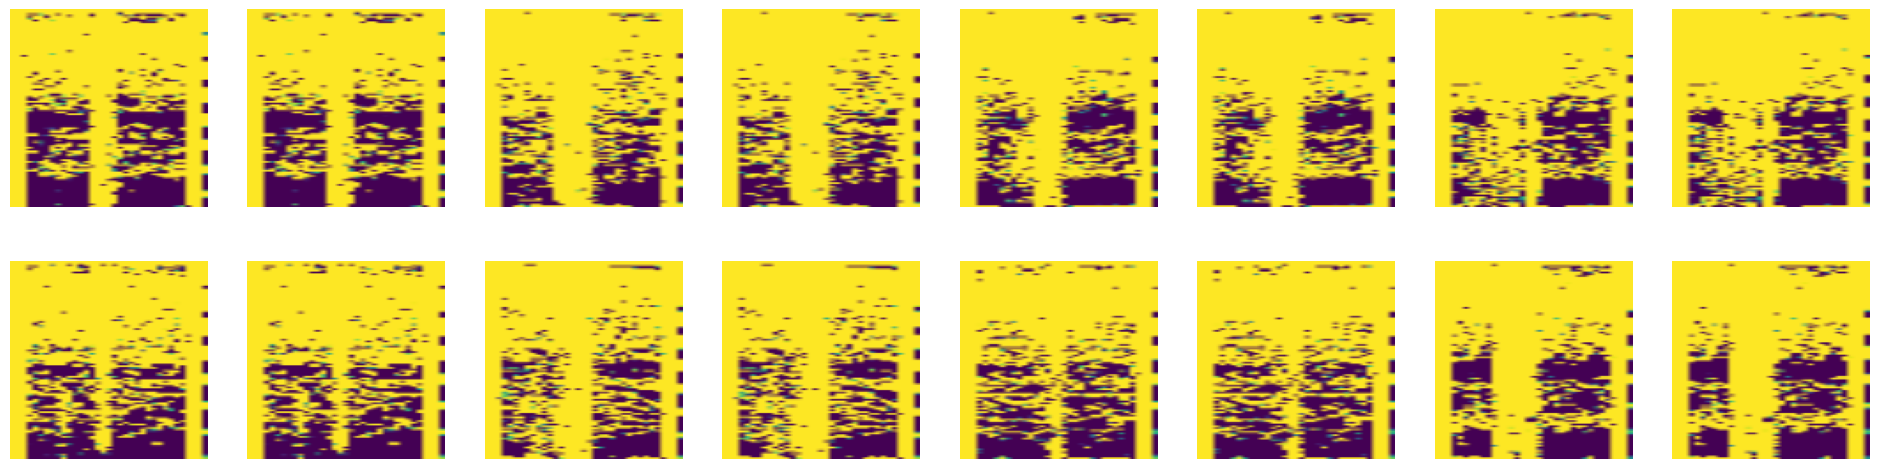

In [12]:
dls.show_batch()

In [13]:
import torch
import torch.nn as nn


class Experimental(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(

            nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 59, 59)
            nn.ReLU(),
            
            nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 29, 29)
            nn.ReLU(),
        
            nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 14, 14)
            nn.ReLU(),
        
            nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
            nn.ReLU(),

        )
    
    
        # ---------- Bottleneck ----------
        self.bottleneck = nn.Sequential(
            nn.Flatten(),                       # [B, 128, 2, 2] → [B, 512]
            nn.Linear(64 * 6 * 6, 64), nn.ReLU(),
            nn.Linear(64, 64 * 6 * 6),  
            nn.Unflatten(1, (64, 6, 6))        # back to [B, 128, 2, 2]
        )
    
        # ---------- Decoder ----------
        self.decoder = nn.Sequential(
    
            # 6 × 6 → 13 × 13
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2),
            nn.ReLU(),
    
            # 13 × 13 → 27 × 27
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2),
            nn.ReLU(),
    
            # 27 × 27 → 55 × 55
            nn.ConvTranspose2d(16, 8, kernel_size=3, stride=2),
            nn.ReLU(),
    
            # 55 × 55 → 112 × 112
            nn.ConvTranspose2d(8, 3, kernel_size=4, stride=2),
            nn.Sigmoid()                         # pixel values in [0, 1]
        )
    
    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        return x

In [14]:
autoencoder = Experimental()

In [16]:
learner = Learner(dls, autoencoder, loss_func=F.mse_loss)

In [ ]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))
learner.fit_one_cycle(n_epoch = 25, lr_max=lr.valley)

In [ ]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))